# Lab 1
## Dynamic model of a multi-link manipulator

## Steps

### 0. Import the necessary libraries

In [18]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model (UR10)

In [19]:
robot = rtb.models.DH.UR10()
print(robot)

DHRobot: UR10 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬────────┬─────────┬────────┐
│ θⱼ  │   dⱼ   │   aⱼ    │   ⍺ⱼ   │
├─────┼────────┼─────────┼────────┤
│  q1 │ 0.1273 │       0 │  90.0° │
│  q2 │      0 │  -0.612 │   0.0° │
│  q3 │      0 │ -0.5723 │   0.0° │
│  q4 │ 0.1639 │       0 │  90.0° │
│  q5 │ 0.1157 │       0 │ -90.0° │
│  q6 │ 0.0922 │       0 │   0.0° │
└─────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



### 2. Fill in the parameters of the robot model 

0. Using dyn() you can view the dynamic parameters of each link

In [20]:
print(robot.links[0].dyn())  # initial dynamic parameters of the first link

m     =       7.1 
r     =     0.021        0    0.027 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =         0 to        0


1. Let's define the mass of the links

In [21]:
# Assign the mass of each link in kilograms.
# These values represent the distribution of the robot weight
# and are required for inertia, gravity, and inverse dynamics calculations.
# from the site https://www.universal-robots.com/articles/ur/application-installation/dh-parameters-for-calculations-of-kinematics-and-dynamics/
robot.links[0].m = 7.1
robot.links[1].m = 12.7
robot.links[2].m = 4.27
robot.links[3].m = 2
robot.links[4].m = 2
robot.links[5].m = 0.365

2. Let's define the center of mass of each link

In [22]:
# also from the same site 
robot.links[0].r = np.array([0.021, 0.000, 0.027])
robot.links[1].r = np.array([0.380, 0.000, 0.158])
robot.links[2].r = np.array([0.240, 0.000, 0.068])
robot.links[3].r = np.array([0.000, 0.007, 0.018])
robot.links[4].r = np.array([0.000, 0.007, 0.018])
robot.links[5].r = np.array([0.000, 0.000, -0.026])

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]
 Since exact inertia tensors were not fully available in the provided material,
 approximate positive-definite inertia values were assigned consistently
 with the link masses and relative dimensions.

In [23]:
# Assign approximate inertia tensor values for each link.
# These values are chosen to be physically consistent with the relative size
# and mass of each UR10 link.
robot.links[0].I = [0.03,   0.03,   0.02,   0, 0, 0]
robot.links[1].I = [0.25,   0.25,   0.04,   0, 0, 0]
robot.links[2].I = [0.10,   0.10,   0.02,   0, 0, 0]
robot.links[3].I = [0.005,  0.005,  0.003,  0, 0, 0]
robot.links[4].I = [0.003,  0.003,  0.002,  0, 0, 0]
robot.links[5].I = [0.001,  0.001,  0.0005, 0, 0, 0]

4. Let's set the moment of inertia of the drive

In [24]:
# Define the motor inertia for each joint drive.
# Larger values are assigned to the first joints because they usually drive
# heavier parts of the manipulator, while smaller values are used for wrist joints.
robot.links[0].Jm = 0.00035
robot.links[1].Jm = 0.00035
robot.links[2].Jm = 0.00025
robot.links[3].Jm = 0.00004
robot.links[4].Jm = 0.00004
robot.links[5].Jm = 0.00002
robot.links[5].Jm = 0.000033

5. Let's define the coefficient of viscous friction of the drive

In [25]:
# Assign viscous friction coefficients for the joint drives.
# These coefficients model velocity-dependent friction in the actuators.
robot.links[0].B = 0.0012
robot.links[1].B = 0.0010
robot.links[2].B = 0.0008
robot.links[3].B = 0.00025
robot.links[4].B = 0.00020
robot.links[5].B = 0.00015

6. Let's define the coefficient of Coulomb friction of the drive

In [26]:
# Assign Coulomb friction coefficients for each joint.
# The first value corresponds to the positive velocity direction,
# and the second value corresponds to the negative velocity direction.
robot.links[0].Tc = [0.35, -0.32]
robot.links[1].Tc = [0.30, -0.28]
robot.links[2].Tc = [0.22, -0.20]
robot.links[3].Tc = [0.08, -0.07]
robot.links[4].Tc = [0.06, -0.05]
robot.links[5].Tc = [0.04, -0.03]

7. Let's set the gear ratio for each link

In [27]:
# Set the gear ratio of each actuator.
# Higher gear ratios are used for the larger joints,
# while smaller ratios are assigned to the wrist joints.
robot.links[0].G = 120
robot.links[1].G = 120
robot.links[2].G = 100
robot.links[3].G = 80
robot.links[4].G = 80
robot.links[5].G = 60

8. Let's set restrictions on the generalized coordinates for each link

In [28]:
# Define the allowable joint position limits in radians.
# These limits constrain the motion of the robot
# and ensure that the chosen configurations are physically valid.
robot.links[0].qlim = [-2*np.pi, 2*np.pi]
robot.links[1].qlim = [-np.pi, np.pi]
robot.links[2].qlim = [-np.pi, np.pi]
robot.links[3].qlim = [-2*np.pi, 2*np.pi]
robot.links[4].qlim = [-2*np.pi, 2*np.pi]
robot.links[5].qlim = [-2*np.pi, 2*np.pi]

### 3. Set the initial and final positions of the robot and plot them

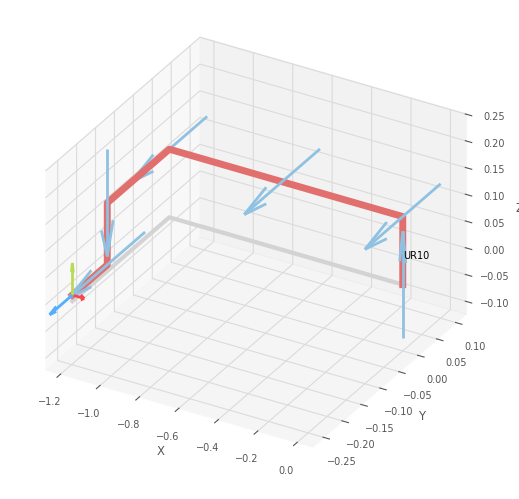

<Figure size 640x480 with 0 Axes>

In [29]:
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

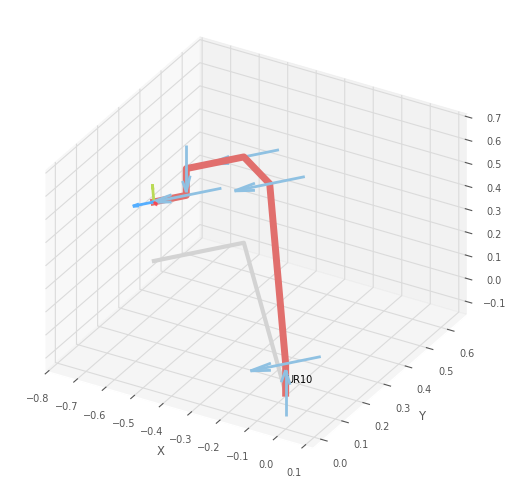

<Figure size 640x480 with 0 Axes>

In [30]:
q_end = [-pi/4, -pi/3, pi/2, -pi/6, 0, pi/6]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions

In [31]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)

### 5. Solve the inverse dynamics

In [32]:
# tau: full dynamic case → includes inertia, Coriolis/centrifugal, and gravity effects
tau = robot.rne(tr.q, tr.qd, tr.qdd).T
# tau_qs: quasi-static case → velocities are present but accelerations are neglected
tau_qs = robot.rne(tr.q, tr.qd, np.zeros([N,6])).T
# tau0: static case → both velocities and accelerations are zero
# only gravity effects remain (holding position)
tau0 = robot.rne(tr.q, np.zeros([N,6]), np.zeros([N,6])).T

### 6. Obtain the components of the dynamic equation

In [33]:
M = robot.inertia(tr.q)
C = robot.coriolis(tr.q, tr.qd)
G = robot.gravload(tr.q)

M0 = robot.inertia(tr.q)
C0 = robot.coriolis(tr.q, np.zeros([N,6]))
G0 = robot.gravload(tr.q)

### 7. Plot the graphs

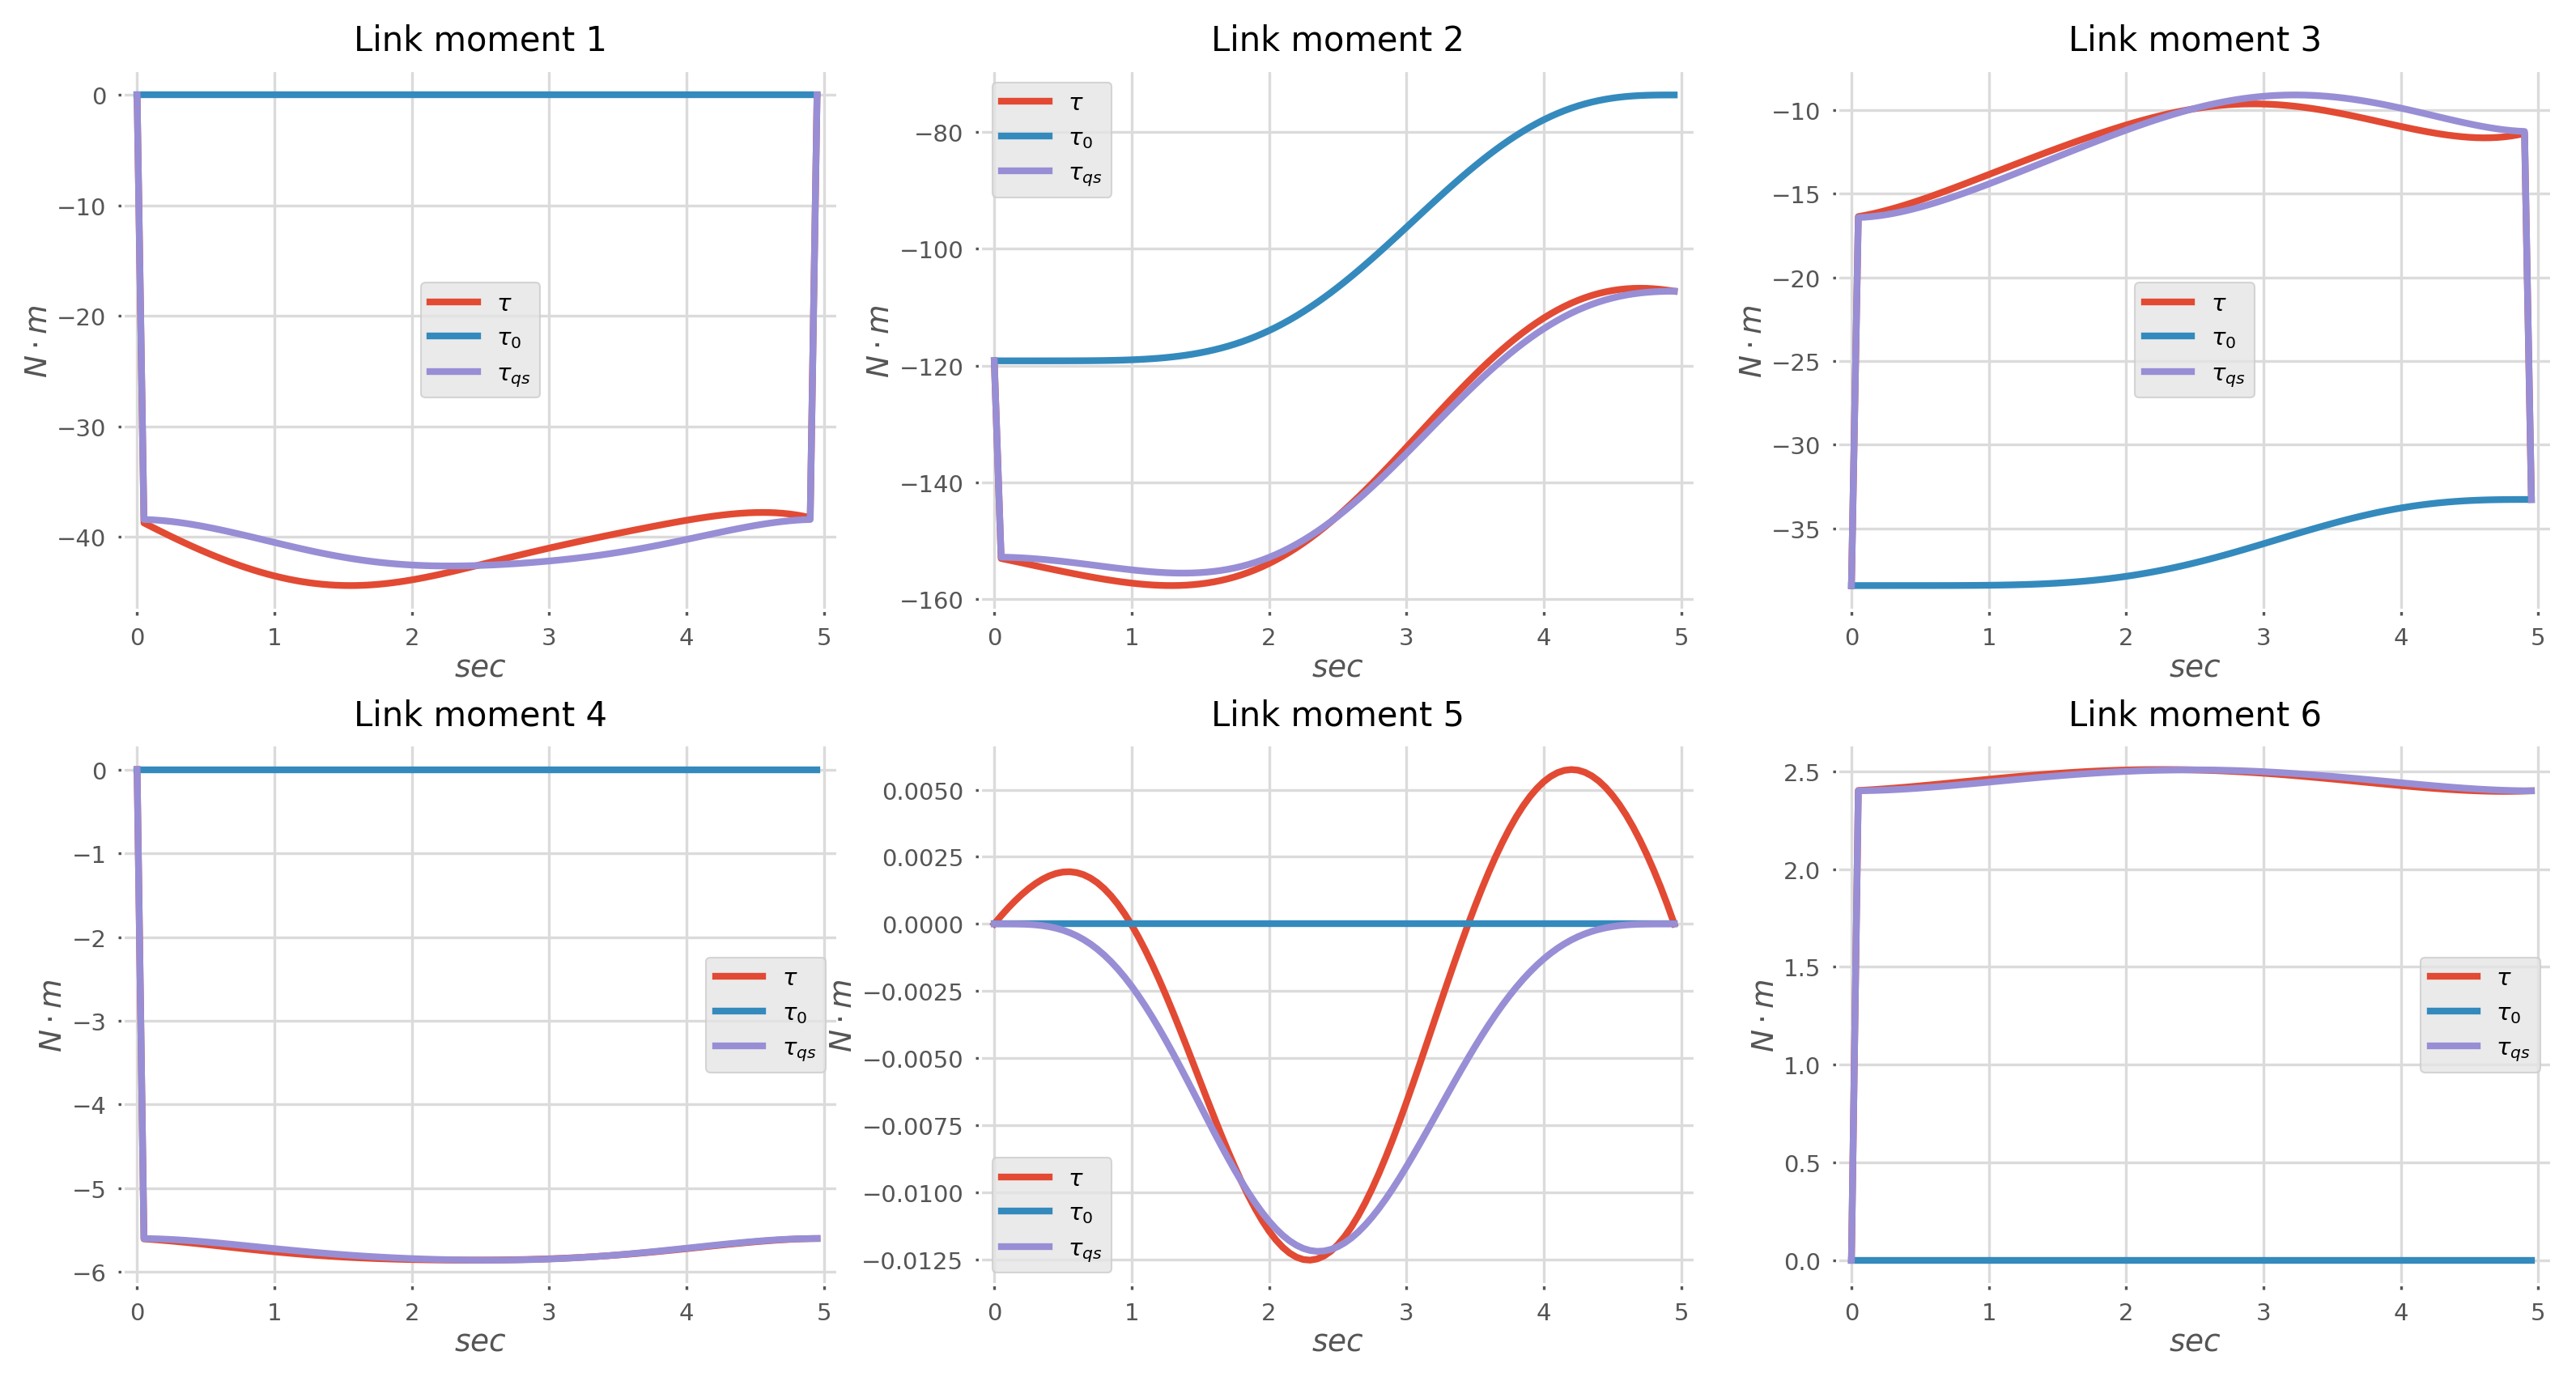

In [34]:
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(6):
    plt.subplot(2,3,g+1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    plt.plot(time, tau[g], linewidth=2, label=r"$\tau$")  # Строим график
    plt.plot(time, tau0[g], linewidth=2, label=r"$\tau_{0}$")  # Строим график
    plt.plot(time, tau_qs[g], linewidth=2, label=r"$\tau_{qs}$")  # Строим график
    plt.title(r"Link moment {}".format(g+1), fontsize=10)  # Название графика
    plt.ylabel(r"$N \cdot m$", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$sec$", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

The obtained torque plots show a clear difference between the three considered inverse dynamics cases.
For joints 1, 2, and 3, the required torques are significantly larger, which is expected since these joints carry most of the manipulator mass.
The static case (τ0) reflects mainly gravity loading, while the quasi-static case (τ_qs) includes the effect of joint velocities with negligible accelerations.
The full dynamic case (τ) additionally includes acceleration-dependent inertial effects.
For wrist joints, especially joints 4, 5, and 6, the torques are much smaller due to the lower masses and inertias of the distal links.